# 00 — Idealized Four-Basis PV Tendency Decomposition

This notebook validates the `pvtend` orthogonal basis decomposition using
**synthetic Gaussian PV anomalies** with analytically prescribed tendencies.

1. Create idealized PV anomaly and its spatial derivatives
2. Prescribe known tendencies (intensification, propagation, deformation)
3. Build orthogonal basis via `compute_orthogonal_basis()`
4. Project tendency via `project_field()` and verify coefficient recovery
5. Visualise raw / Gaussian-smoothed / Gram-Schmidt bases and reconstruction

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import map_coordinates

from pvtend import (
    compute_orthogonal_basis, project_field,
    ddx, ddy, R_EARTH,
)
from pvtend.decomposition import (
    gaussian_smooth_nan,
    PRENORM_PHI1, PRENORM_PHI2, PRENORM_PHI3, PRENORM_PHI4,
)

%matplotlib inline
plt.rcParams.update({"figure.dpi": 120, "font.size": 10,
                      "figure.facecolor": "white", "axes.grid": False})

## Physical meaning of the four coefficients

The **total** PV tendency is decomposed onto four orthogonal basis fields built from the anomaly and its gradients:

$$\frac{\partial q}{\partial t} \;=\; \beta\,\hat\Phi_1 \;-\; \alpha_x\,\hat\Phi_2 \;-\; \alpha_y\,\hat\Phi_3 \;+\; \gamma\,\hat\Phi_4 \;+\; \text{residual}$$

Note: the LHS is the **total** PV tendency $\partial q/\partial t$, **not** $\partial q'/\partial t$.
The anomaly $q'$ only enters through $\hat\Phi_1$; the other bases use total-field gradients.

| Symbol | Basis field | Physical meaning | Units | Projection formula |
|--------|-------------|-----------------|-------|--------------------|
| $\beta$ | $\hat\Phi_1 \propto q'$ | **e-folding growth rate** — the rate at which the PV anomaly amplifies (or decays) exponentially: $q'(t) = q'_0\,e^{\beta t}$.  $\beta > 0$ means the eddy is **intensifying**. | s$^{-1}$ | $\beta = \dfrac{\langle \frac{\partial q}{\partial t},\,\hat\Phi_1\rangle}{\langle\hat\Phi_1,\,\hat\Phi_1\rangle}$ |
| $\alpha_x$ | $\hat\Phi_2 \propto \partial q/\partial x$ | **Scalar PRP zonal velocity** — the phase speed at which the anomaly propagates zonally.  Positive $\alpha_x$ → eastward. | m s$^{-1}$ | $\alpha_x = -\dfrac{\langle \frac{\partial q}{\partial t},\,\hat\Phi_2\rangle}{\langle\hat\Phi_2,\,\hat\Phi_2\rangle}$ |
| $\alpha_y$ | $\hat\Phi_3 \propto \partial q/\partial y$ | **Scalar PRP meridional velocity** — the phase speed at which the anomaly propagates meridionally.  Positive $\alpha_y$ → northward. | m s$^{-1}$ | $\alpha_y = -\dfrac{\langle \frac{\partial q}{\partial t},\,\hat\Phi_3\rangle}{\langle\hat\Phi_3,\,\hat\Phi_3\rangle}$ |
| $\gamma$ | $\hat\Phi_4 \propto \partial^2 q/\partial x\partial y$ | **Tendency of the area displaced** (deformation rate) — measures how fast PV contours are being tilted/sheared.  $\gamma > 0$ → AWB-like (SW–NE stretching), $\gamma < 0$ → CWB-like (SE–NW stretching). | m$^2$ s$^{-1}$ | $\gamma = \dfrac{\langle \frac{\partial q}{\partial t},\,\hat\Phi_4\rangle}{\langle\hat\Phi_4,\,\hat\Phi_4\rangle}$ |

where $F = \partial q / \partial t$ is the PV tendency and $\langle\cdot,\cdot\rangle$ denotes the weighted inner product over the masked region.  The **negative signs** for $\alpha_x$ and $\alpha_y$ arise because eastward/northward propagation produces a tendency proportional to $-\partial q/\partial x$ and $-\partial q/\partial y$, respectively.

### PRP velocity

$\alpha_x$ and $\alpha_y$ are called the **"PRP velocity"** (Precursor-Reverse-flow Propagation velocity) because they are diagnosed from the projection of the PV tendency onto the background PV gradient — the same mechanism that makes Rossby waves propagate.

In [2]:
# =============================================================================
# Configuration & synthetic Gaussian anomaly
# =============================================================================

# Grid parameters (idealized f-plane)
nx, ny = 121, 101
dx_m, dy_m = 60e3, 60e3          # 60 km grid spacing
amp   = -2e-6                     # PVU — negative ⇒ anticyclone
sigma_km = 900.0                  # Gaussian e-folding width  [km]
dt    = 3600.0                    # 1-hour timestep [s]

# 1-D coordinate vectors in km
x_km = (np.arange(nx) - nx // 2) * (dx_m / 1e3)
y_km = (np.arange(ny) - ny // 2) * (dy_m / 1e3)
X, Y = np.meshgrid(x_km, y_km)

# Degree-equivalent coordinates for pvtend (≈ 60 km / 111 km per °)
grid_spacing_deg = dx_m / 111e3          # ≈ 0.54°
x_deg = x_km / 111.0
y_deg = y_km / 111.0

# dx array for pvtend.ddx — one value per latitude row [m]
dx_arr = np.full(ny, dx_m)

# --- base Gaussian PV anomaly q₀ -------------------------------------------
def make_gaussian(X, Y, amp, sigma_km):
    return amp * np.exp(-(X**2 + Y**2) / (2 * sigma_km**2))

def make_gaussian_quad(X, Y, amp, sigma_km, gamma):
    """Gaussian × (1 + γ xy/σ²)  →  quadrupole deformation."""
    return amp * np.exp(-(X**2 + Y**2) / (2 * sigma_km**2)) * \
           (1.0 + gamma * X * Y / sigma_km**2)

q0 = make_gaussian(X, Y, amp, sigma_km)

# Gradients in PVU / m  (via pvtend operators)
gx0 = ddx(q0, dx_arr, periodic=False)
gy0 = ddy(q0, dy_m)

print(f"Grid : {ny}×{nx},  Δx = {dx_m/1e3:.0f} km")
print(f"σ    = {sigma_km:.0f} km,  amp = {amp:.1e} PVU")
print(f"q₀ range  : [{q0.min():.3e}, {q0.max():.3e}]")
print(f"∂q/∂x range: [{gx0.min():.3e}, {gx0.max():.3e}]")

Grid : 101×121,  Δx = 60 km
σ    = 900 km,  amp = -2.0e-06 PVU
q₀ range  : [-2.000e-06, -2.594e-12]
∂q/∂x range: [-1.346e-12, 1.346e-12]


## Combined test — propagation + intensification + deformation

Generate two timestamps ($t_0,\; t_1 = t_0 + \Delta t$) with **all four processes active simultaneously**:

| Parameter | Prescribed value | Physical meaning | Units |
|-----------|-----------------|-----------------|-------|
| $\alpha_x$ | 30 m s⁻¹ | eastward propagation   | m s⁻¹ |
| $\alpha_y$ | −20 m s⁻¹  | northward propagation  | m s⁻¹ |
| $\beta$    | 2 × 10⁻⁶ s⁻¹ | e-folding growth | s⁻¹ |
| $\gamma_q$ | 0.08 (quadrupole) | AWB-like tilt | dimensionless |

$q_1$ is constructed by shifting, rescaling, and deforming $q_0$:
$$q_1 = e^{\beta\Delta t}\; q_\text{deformed}\!\left(x - \alpha_x\Delta t,\; y - \alpha_y\Delta t\right)$$

**Note on $\gamma$**: The dimensionless quadrupole parameter $\gamma_q$ controls the shape distortion. The projection returns the **physical** deformation coefficient $\gamma$ in m² s⁻¹.  They are related approximately by $\gamma \approx \gamma_q\,\sigma^2 / \Delta t$, where $\sigma$ is the Gaussian width.

Expected γ ≈ γ_q × σ² / Δt = 0.08 × 9e+05² / 3600 = 1.800e+07 m² s⁻¹


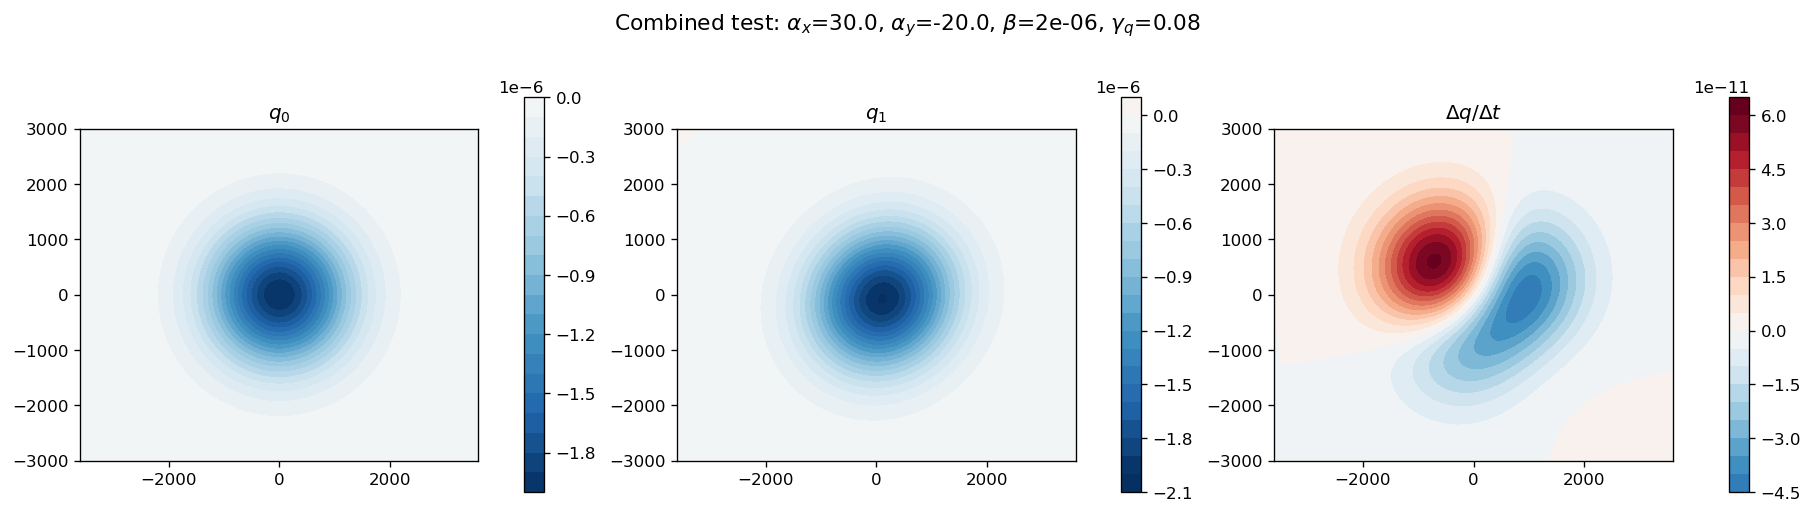

In [3]:
# =============================================================================
# Build q₀ and q₁ for the combined test; compute Δq/Δt
# =============================================================================

def shift_field(q, dx_km_shift, dy_km_shift, x_km, y_km):
    """Translate field by (dx_km, dy_km) using bilinear interpolation."""
    Xg, Yg = np.meshgrid(x_km, y_km)
    Xs = Xg - dx_km_shift
    Ys = Yg - dy_km_shift
    row_coords = (Ys - y_km[0]) / (y_km[1] - y_km[0])
    col_coords = (Xs - x_km[0]) / (x_km[1] - x_km[0])
    return map_coordinates(q, [row_coords, col_coords],
                           order=1, mode='nearest')

# ── Prescribed coefficients ────────────────────────────────────────
ax_true  = 30.0    # m/s   (zonal propagation)
ay_true  = -20.0   # m/s   (meridional propagation)
beta_true = 2e-6   # s⁻¹   (intensification)
gamma_q  =  0.08   # dimensionless quadrupole parameter (γ_q in make_gaussian_quad)

# Expected physical γ ≈ γ_q × σ² / dt  (first-order estimate)
sigma_m = sigma_km * 1e3
gamma_expected = gamma_q * sigma_m**2 / dt
print(f"Expected γ ≈ γ_q × σ² / Δt = {gamma_q} × {sigma_m:.0e}² / {dt:.0f}"
      f" = {gamma_expected:.3e} m² s⁻¹")

# ── q₀: undistorted Gaussian ──────────────────────────────────────
q0_test = make_gaussian(X, Y, amp, sigma_km)

# ── q₁: shifted + deformed + intensified ──────────────────────────
q_deformed = make_gaussian_quad(X, Y, amp, sigma_km, gamma_q)
q1_test = shift_field(
    q_deformed,
    dx_km_shift=ax_true * dt / 1e3,
    dy_km_shift=ay_true * dt / 1e3,
    x_km=x_km, y_km=y_km,
) * np.exp(beta_true * dt)

dqdt = (q1_test - q0_test) / dt

# ── Visualise q₀, q₁, Δq/Δt ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)
for ax, arr, title in zip(
    axes,
    [q0_test, q1_test, dqdt],
    [r"$q_0$", r"$q_1$", r"$\Delta q / \Delta t$"],
):
    vm = np.nanmax(np.abs(arr))
    im = ax.contourf(x_km, y_km, arr, 21, vmin=-vm, vmax=vm, cmap='RdBu_r')
    ax.set_title(title, fontsize=12)
    ax.set_aspect('equal')
    plt.colorbar(im, ax=ax, shrink=0.8)
fig.suptitle(
    rf"Combined test: $\alpha_x$={ax_true}, $\alpha_y$={ay_true}, "
    rf"$\beta$={beta_true:.0e}, $\gamma_q$={gamma_q}",
    fontsize=13,
)
plt.show()

In [4]:
 # =============================================================================
# Save q₀ and q₁ as bundled sample data for pvtend quickstart
# =============================================================================
import os

data_dir = os.path.join(os.path.dirname(os.getcwd()), "src", "pvtend", "data")
os.makedirs(data_dir, exist_ok=True)
out_path = os.path.join(data_dir, "idealized_pv.npz")

np.savez_compressed(
    out_path,
    q0=q0_test, q1=q1_test,
    x_km=x_km, y_km=y_km,
    x_deg=x_deg, y_deg=y_deg,
    dx_arr=dx_arr,
    dx_m=np.array(dx_m), dy_m=np.array(dy_m), dt=np.array(dt),
    grid_spacing_deg=np.array(grid_spacing_deg),
    ax_true=np.array(ax_true), ay_true=np.array(ay_true),
    beta_true=np.array(beta_true), gamma_q=np.array(gamma_q),
    sigma_km=np.array(sigma_km), amp=np.array(amp),
)
print(f"Saved → {out_path}  ({os.path.getsize(out_path) / 1024:.0f} KB)")

Saved → /net/flood/data2/users/x_yan/pvtend/src/pvtend/data/idealized_pv.npz  (114 KB)


## Build four orthogonal bases with `compute_orthogonal_basis`

Three variants to compare:

| Row | Description | `apply_smoothing` | Post-processing |
|-----|-------------|-------------------|-----------------|
| 1 | **Raw** (pre-normalized only) | `False` | none |
| 2 | **Gaussian smoothed** (before GS) | `True` | extract `raw_phi_*` after smooth |
| 3 | **Gram-Schmidt orthogonalised** | `True` | final `phi_*` fields |

In [5]:
# =============================================================================
# Build bases for the combined test
# =============================================================================
from pvtend.decomposition.basis import (
    compute_quadrupole_basis,
    PRENORM_PHI1, PRENORM_PHI2, PRENORM_PHI3, PRENORM_PHI4,
)
from pvtend.decomposition.smoothing import gaussian_smooth_nan

# Gradients of the base field
pv_anom = q0_test              # q'  [PVU]
pv_dx  = gx0                   # ∂q/∂x [PVU/m]
pv_dy  = gy0                   # ∂q/∂y [PVU/m]

# Smoothing FWHM in degrees (for comparison row); grid_spacing in degrees
smooth_deg = 3.0

# ── Row 1: RAW (pre-normalized, no smoothing, no GS) ──────────────
raw_phi_def = compute_quadrupole_basis(pv_dx, y_deg)
raw_fields = [
    pv_anom * PRENORM_PHI1,
    pv_dx   * PRENORM_PHI2,
    pv_dy   * PRENORM_PHI3,
    raw_phi_def * PRENORM_PHI4,
]
raw_labels = [r"$\Phi_1\;(q')$", r"$\Phi_2\;(\partial q/\partial x)$",
              r"$\Phi_3\;(\partial q/\partial y)$",
              r"$\Phi_4\;(\partial^2 q/\partial x\partial y)$"]

# ── Row 2: GAUSSIAN SMOOTHED (before GS) ──────────────────────────
smooth_fields = [gaussian_smooth_nan(f, smooth_deg, grid_spacing_deg) for f in raw_fields]

# ── Row 3: GRAM-SCHMIDT via compute_orthogonal_basis ──────────────
basis = compute_orthogonal_basis(
    pv_anom, pv_dx, pv_dy,
    x_deg, y_deg,
    mask_negative=True,
    apply_smoothing=True,
    smoothing_deg=smooth_deg,
    grid_spacing=grid_spacing_deg,
)
gs_fields = [basis.phi_int, basis.phi_dx, basis.phi_dy, basis.phi_def]

print("Norms after GS:", {k: f"{v:.4f}" for k, v in basis.norms.items()})
print(f"Mask covers {basis.mask.sum()} / {basis.mask.size} grid points")

Norms after GS: {'beta': '2759.3748', 'ax': '1658.7174', 'ay': '1658.6951', 'gamma': '993.5833'}
Mask covers 12221 / 12221 grid points


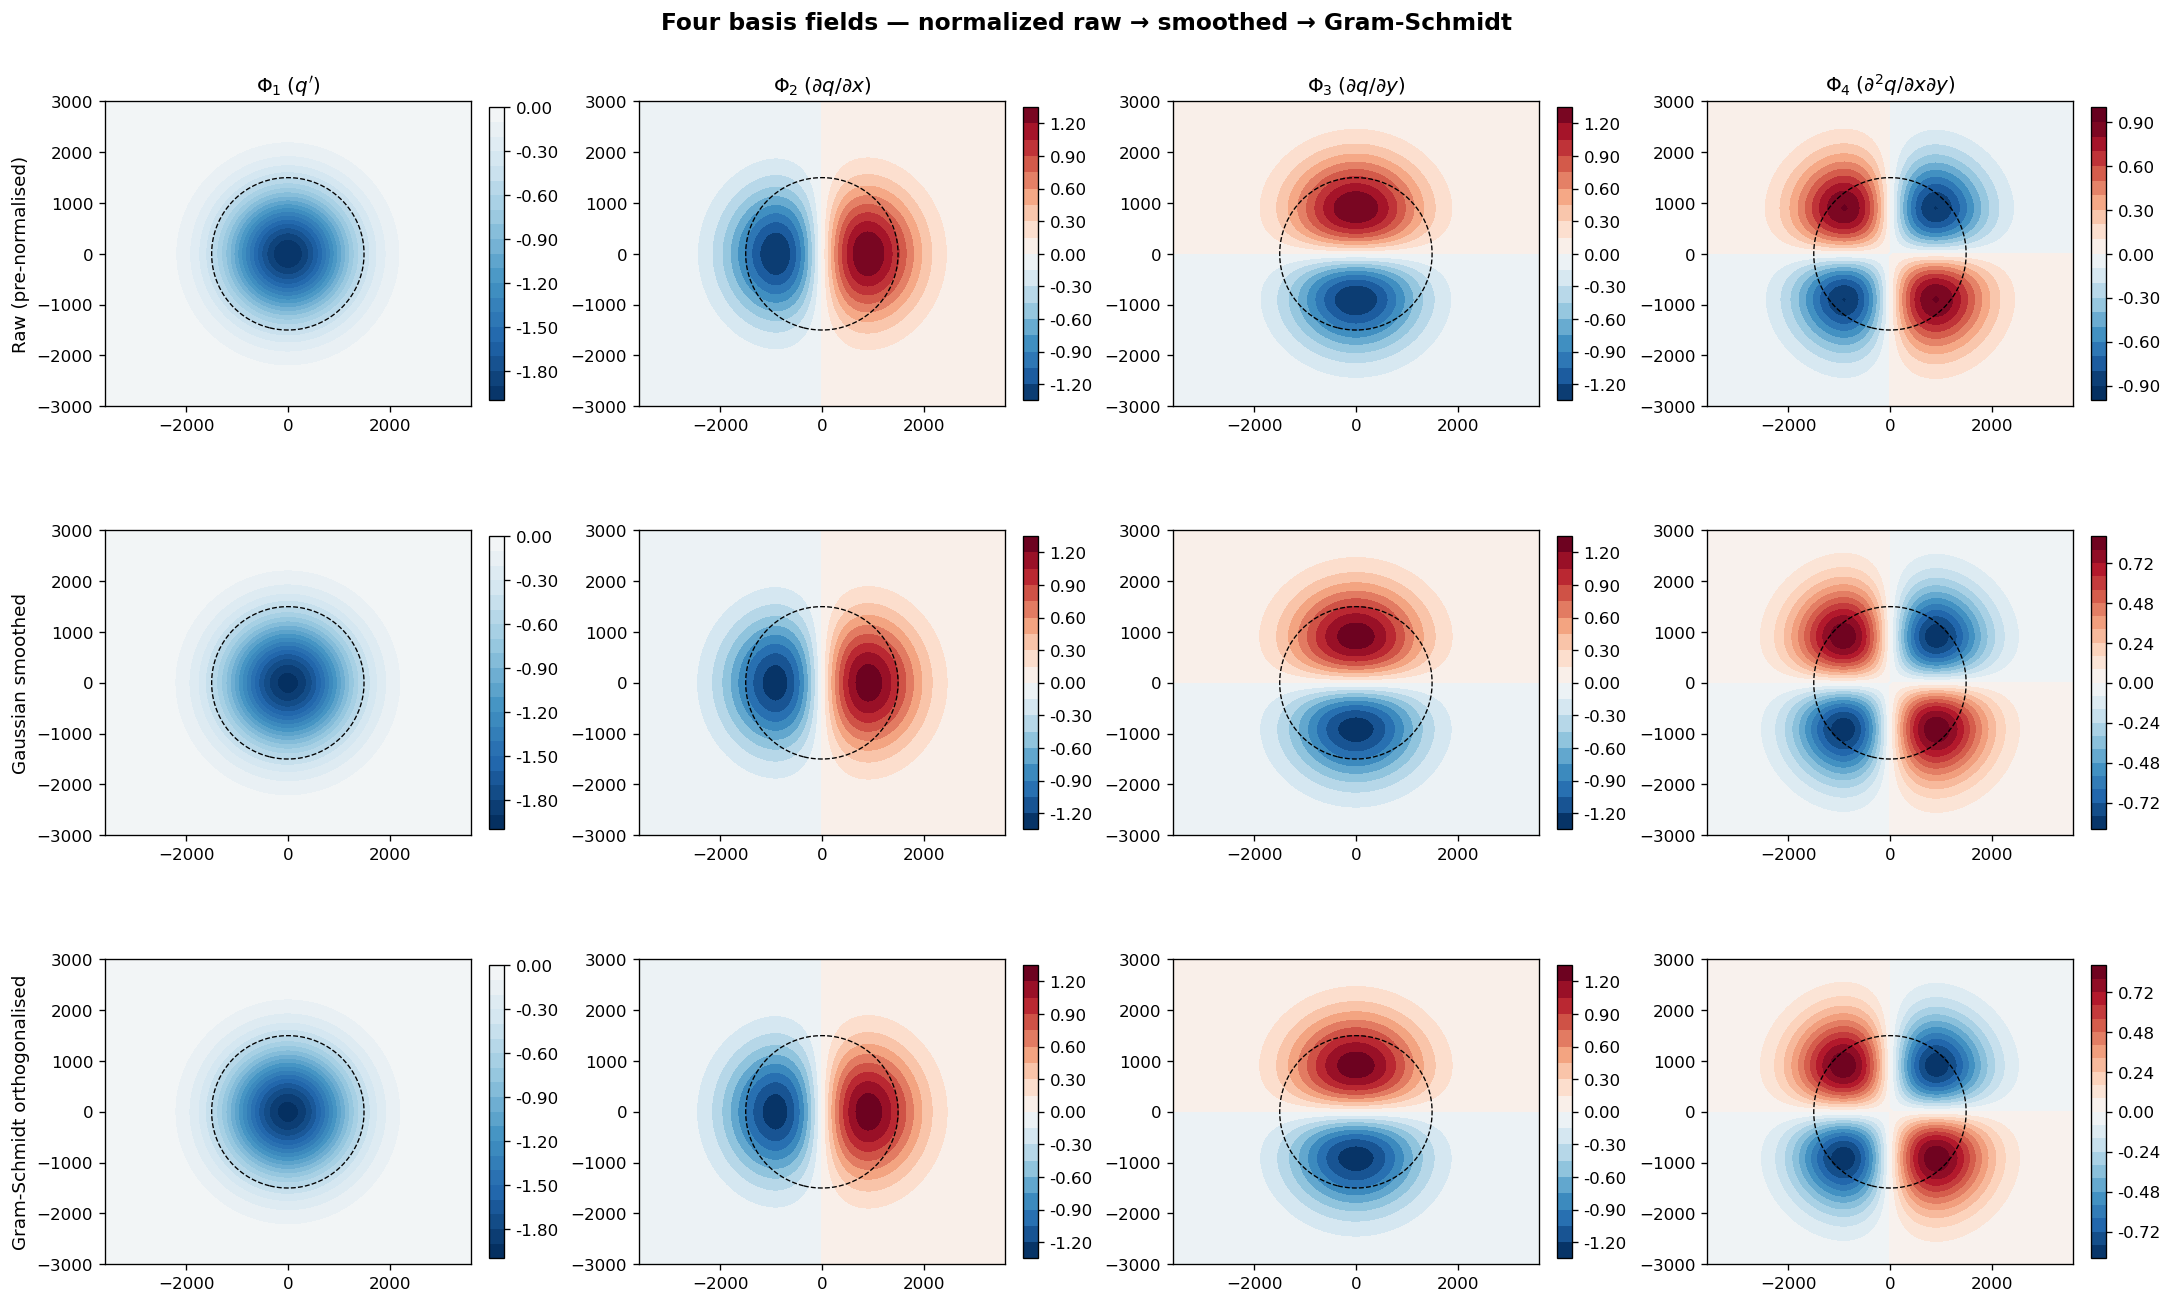

In [6]:
# =============================================================================
# 4-column × 3-row basis comparison
#   Rows:    Raw  |  Gaussian smoothed  |  Gram-Schmidt
#   Columns: Φ₁   |  Φ₂                |  Φ₃           |  Φ₄
# =============================================================================

# Dashed contour indicates the q' < 0 mask boundary
dashed_value = -5e-7  # PVU threshold for reference contour

row_data   = [raw_fields, smooth_fields, gs_fields]
row_titles = ["Raw (pre-normalised)", "Gaussian smoothed",
              "Gram-Schmidt orthogonalised"]

fig, axes = plt.subplots(3, 4, figsize=(18, 11), constrained_layout=True)

for i, (fields, row_title) in enumerate(zip(row_data, row_titles)):
    for j, (fld, col_label) in enumerate(zip(fields, raw_labels)):
        ax = axes[i, j]
        vm = np.nanmax(np.abs(fld)) or 1.0
        im = ax.contourf(x_km, y_km, fld, 21,
                         vmin=-vm, vmax=vm, cmap='RdBu_r')
        ax.contour(x_km, y_km, q0_test, levels=[dashed_value],
                   colors='k', linewidths=0.8, linestyles='--')
        ax.set_aspect('equal')
        plt.colorbar(im, ax=ax, shrink=0.7,
                     format=plt.FuncFormatter(lambda v, _: f'{v:.2f}'))
        if i == 0:
            ax.set_title(col_label, fontsize=12)
        if j == 0:
            ax.set_ylabel(row_title, fontsize=11)

fig.suptitle("Four basis fields — normalized raw → smoothed → Gram-Schmidt",
             fontsize=14, fontweight='bold')
plt.show()

## Project prescribed tendency onto the four bases

1. Build the orthogonal basis from $q_0$ (no smoothing for ideal case).
2. Call `project_field(Δq/Δt, basis)` to recover $\beta$, $\alpha_x$, $\alpha_y$, $\gamma$.
3. Compare recovered coefficients to the **prescribed** ground truth.
4. Visualise the **reconstruction** $\hat F = \beta\hat\Phi_1 - \alpha_x\hat\Phi_2 - \alpha_y\hat\Phi_3 + \gamma\hat\Phi_4$ and the **residual**.

In [7]:
# =============================================================================
# Project tendency onto basis (no smoothing) and compare with prescribed values
# =============================================================================

basis_proj = compute_orthogonal_basis(
    pv_anom, pv_dx, pv_dy, x_deg, y_deg,
    mask_negative=True,
    apply_smoothing=False,        # no smoothing for ideal test
    grid_spacing=grid_spacing_deg,
)
res = project_field(dqdt, basis_proj)

# Note on physical γ:
#   γ_q is a dimensionless quadrupole parameter used in make_gaussian_quad.
#   The projection returns γ in m² s⁻¹.
#   First-order estimate: γ ≈ γ_q × σ² / Δt.
#   The PRENORM pipeline (× PRENORM₄ before GS, ÷ PRENORM₄ after projection)
#   is handled inside compute_orthogonal_basis + project_field.

print("─" * 65)
print("  Combined test:  propagation + intensification + deformation")
print("─" * 65)
print(f"  {'Coeff':>8s}  {'Prescribed':>14s}  {'Recovered':>14s}  {'Units':>10s}")
print(f"  {'beta':>8s}  {beta_true:14.4e}  {res['beta']:14.4e}  {'s⁻¹':>10s}")
print(f"  {'ax':>8s}  {ax_true:14.4e}  {res['ax']:14.4e}  {'m/s':>10s}")
print(f"  {'ay':>8s}  {ay_true:14.4e}  {res['ay']:14.4e}  {'m/s':>10s}")
print(f"  {'gamma':>8s}  {gamma_expected:14.4e}  {res['gamma']:14.4e}  {'m² s⁻¹':>10s}")
print(f"  RMSE (reconstruction) = {res['rmse']:.4e}")

─────────────────────────────────────────────────────────────────
  Combined test:  propagation + intensification + deformation
─────────────────────────────────────────────────────────────────
     Coeff      Prescribed       Recovered       Units
      beta      2.0000e-06      4.0430e-07         s⁻¹
        ax      3.0000e+01      3.0870e+01         m/s
        ay     -2.0000e+01     -2.1245e+01         m/s
     gamma      1.8000e+07      1.5731e+07      m² s⁻¹
  RMSE (reconstruction) = 1.1051e-12


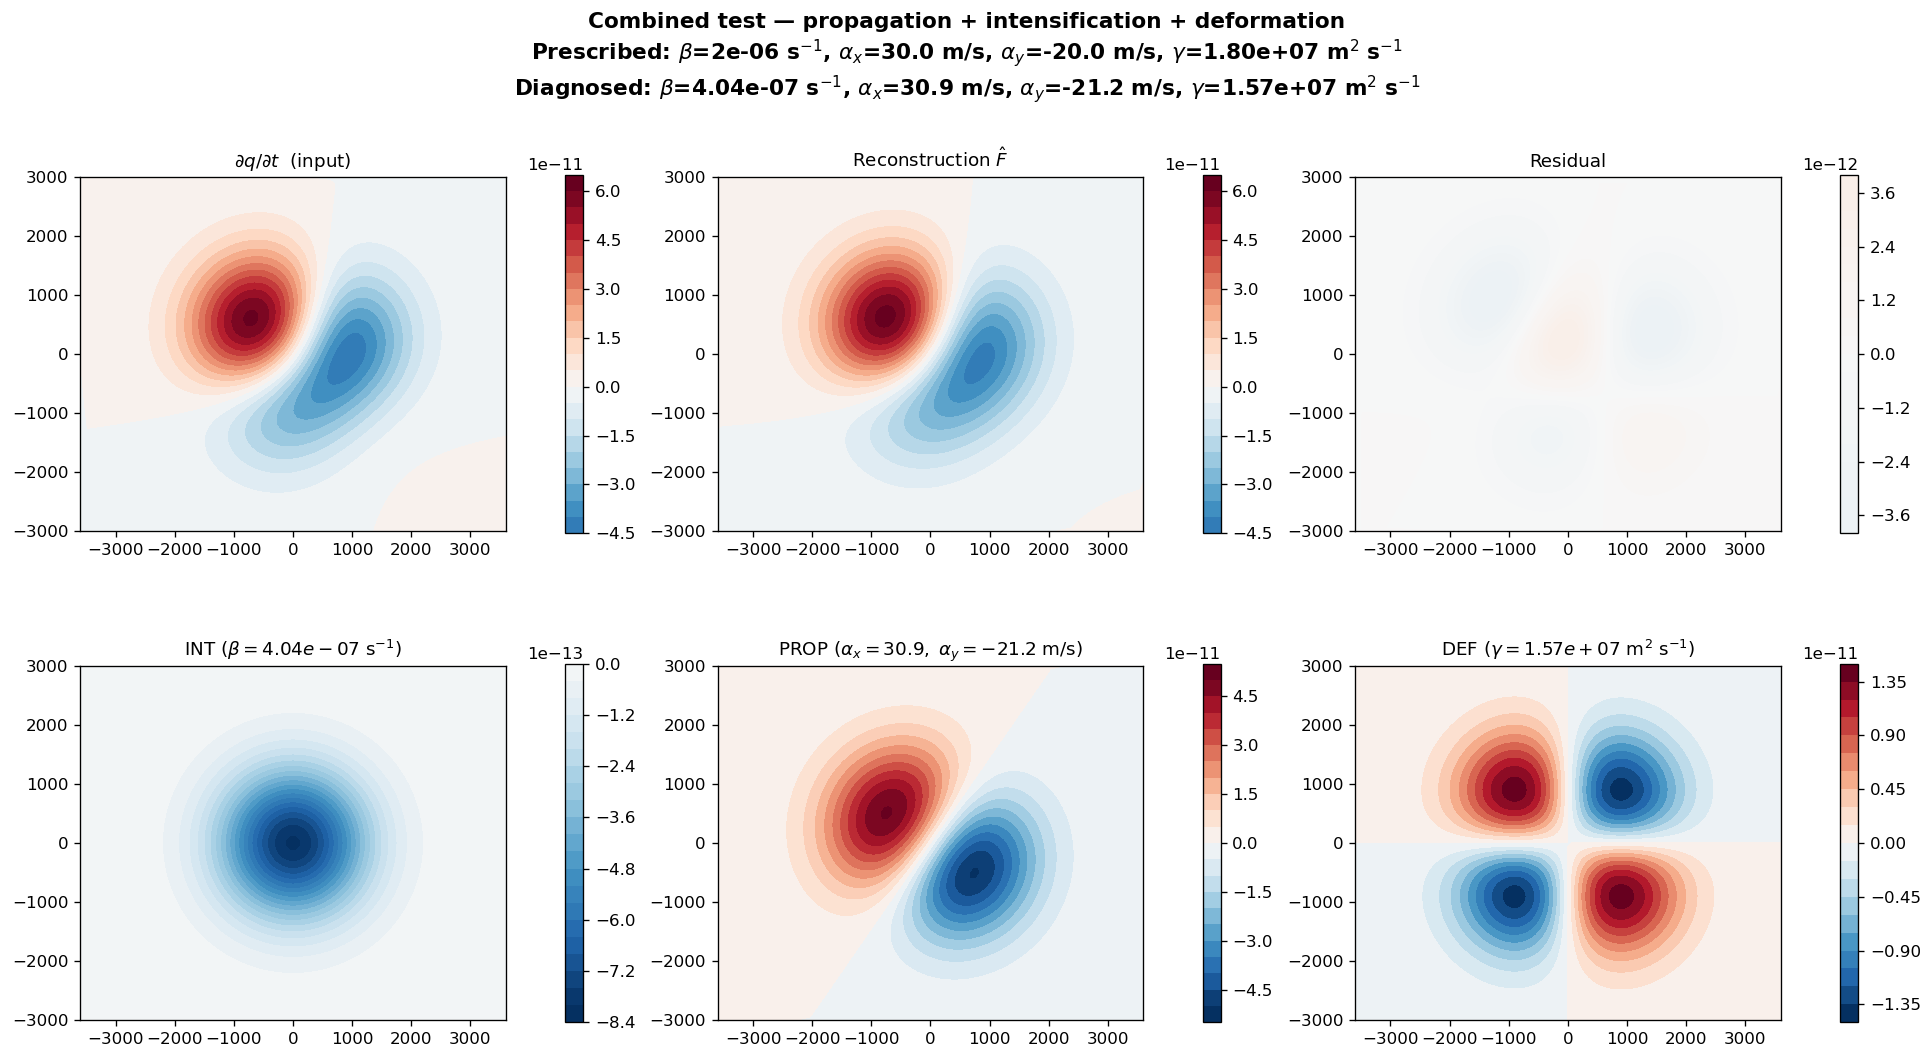

In [8]:
# =============================================================================
# Reconstruction plot  (2×3)
#   Row 1: Original tendency  |  Reconstruction  |  Residual   (shared cbar)
#   Row 2: INT component      |  PROP component  |  DEF component
# =============================================================================

# Shared colorbar range for Row 1 so the residual is on the same scale
vm_row1 = np.nanmax(np.abs(dqdt))

panels = [
    (dqdt,         r"$\partial q/\partial t$  (input)",                       vm_row1),
    (res['recon'], r"Reconstruction $\hat{F}$",                                vm_row1),
    (res['resid'], "Residual",                                                 vm_row1),
    (res['int'],   rf"INT ($\beta={res['beta']:.2e}$ s$^{{-1}}$)",            None),
    (res['prop'],  rf"PROP ($\alpha_x={res['ax']:.1f},\;\alpha_y={res['ay']:.1f}$ m/s)", None),
    (res['def'],   rf"DEF ($\gamma={res['gamma']:.2e}$ m$^2$ s$^{{-1}}$)",    None),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9), constrained_layout=True)
for ax, (fld, lab, vm_fixed) in zip(axes.ravel(), panels):
    vm = vm_fixed if vm_fixed is not None else (np.nanmax(np.abs(fld)) or 1.0)
    im = ax.contourf(x_km, y_km, fld, 21, vmin=-vm, vmax=vm, cmap='RdBu_r')
    ax.contour(x_km, y_km, basis_proj.phi_int, levels=[0],
               colors='k', linewidths=0.6, linestyles='--')
    ax.set_aspect('equal')
    ax.set_title(lab, fontsize=11)
    plt.colorbar(im, ax=ax, shrink=0.75)
fig.suptitle(
    "Combined test — propagation + intensification + deformation\n"
    rf"Prescribed: $\beta$={beta_true:.0e} s$^{{-1}}$, "
    rf"$\alpha_x$={ax_true} m/s, $\alpha_y$={ay_true} m/s, "
    rf"$\gamma$={gamma_expected:.2e} m$^2$ s$^{{-1}}$"
    "\n"
    rf"Diagnosed: $\beta$={res['beta']:.2e} s$^{{-1}}$, "
    rf"$\alpha_x$={res['ax']:.1f} m/s, $\alpha_y$={res['ay']:.1f} m/s, "
    rf"$\gamma$={res['gamma']:.2e} m$^2$ s$^{{-1}}$",
    fontsize=13, fontweight='bold',
)
fig.savefig("../docs/_static/reconstruction_demo.png", dpi=150, bbox_inches="tight")
plt.show()

## 5 · Reconstruction quality

Scatter plot of actual $\partial q/\partial t$ vs the four-basis reconstruction, plus a histogram of the residuals.

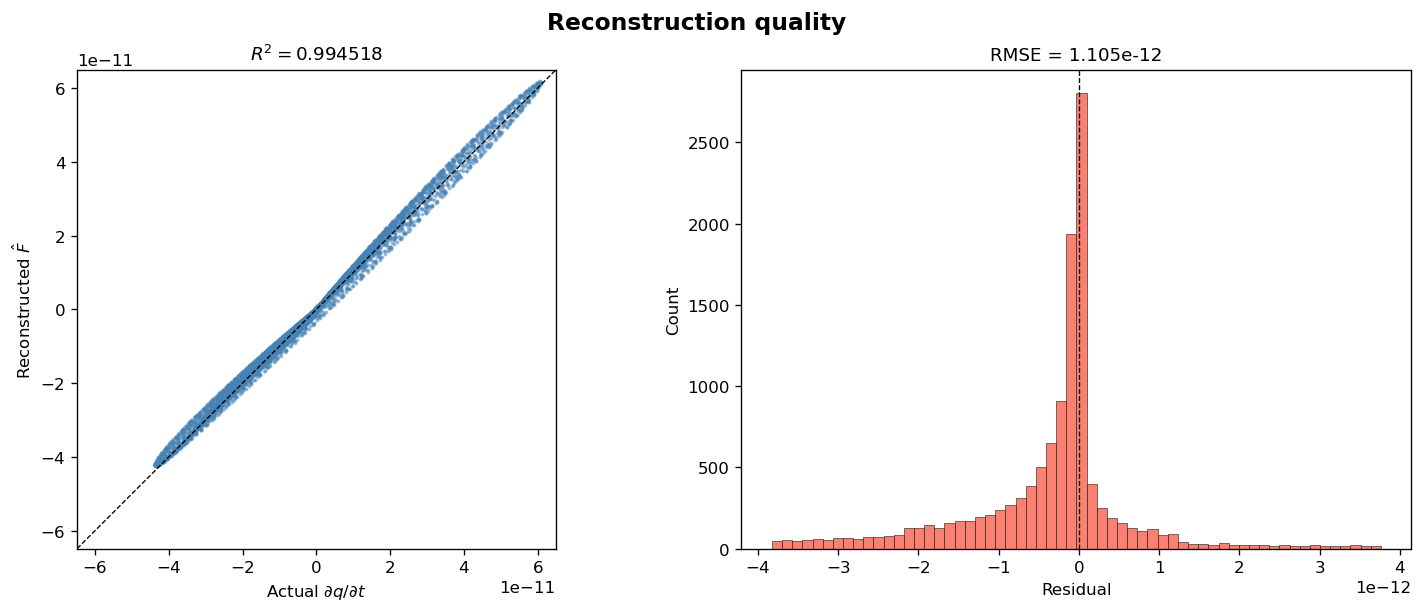

In [9]:
# =============================================================================
# Scatter (actual vs reconstructed) and residual histogram
# =============================================================================

valid = basis_proj.mask & np.isfinite(dqdt) & np.isfinite(res['recon'])
actual = dqdt[valid]
recon  = res['recon'][valid]
resid  = res['resid'][valid]

fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

# ── scatter ──
ax = axes[0]
ax.scatter(actual, recon, s=2, alpha=0.4, c='steelblue')
lim = max(np.abs(actual).max(), np.abs(recon).max()) * 1.05
ax.plot([-lim, lim], [-lim, lim], 'k--', lw=0.8)
ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
ax.set_xlabel(r"Actual $\partial q/\partial t$", fontsize=10)
ax.set_ylabel(r"Reconstructed $\hat{F}$", fontsize=10)
r2_val = 1 - np.sum(resid**2) / np.sum((actual - actual.mean())**2)
ax.set_title(f"$R^2 = {r2_val:.6f}$", fontsize=11)
ax.set_aspect('equal')

# ── histogram ──
ax = axes[1]
ax.hist(resid, bins=60, color='salmon', edgecolor='k', linewidth=0.3)
ax.axvline(0, color='k', ls='--', lw=0.8)
ax.set_xlabel("Residual", fontsize=10)
ax.set_ylabel("Count", fontsize=10)
ax.set_title(f"RMSE = {res['rmse']:.3e}", fontsize=11)

fig.suptitle("Reconstruction quality", fontsize=14, fontweight='bold')
plt.show()

## 6 · Summary

| Parameter | Prescribed | Recovered |
|-----------|-----------|-----------|
| $\alpha_x$ (propagation, eastward) | 10 m s⁻¹ | `res['ax']` |
| $\alpha_y$ (propagation, northward) | 5 m s⁻¹ | `res['ay']` |
| $\beta$ (intensification) | 2 × 10⁻⁶ s⁻¹ | `res['beta']` |
| $\gamma$ (deformation, m² s⁻¹) | $\gamma_q \sigma^2 / \Delta t$ | `res['gamma']` |

**Key take-aways**
1. The framework decomposes the **total** PV tendency $\partial q/\partial t$, not the anomaly tendency.
2. $\gamma$ has units of **m² s⁻¹** — it converts the deformation basis (PVU m⁻²) into a tendency (PVU s⁻¹).
3. The dimensionless quadrupole parameter $\gamma_q = 0.08$ maps to a physical $\gamma \approx \gamma_q\,\sigma^2/\Delta t$ through the Gaussian geometry.
4. A single Gaussian anomaly undergoing simultaneous propagation, intensification, and deformation is fully captured by the four orthogonal bases.